Лабораторная 5

Обучите (или дообучите) нейронную сеть детектировать номера на изображениях (номер представляет собой последовательность длиной до 20 символов из цифр, прописных и строчных букв русского или английского алфавита, знаков дефис и слеш).

In [1]:
import torch

device = torch.device('cuda')
torch.backends.cudnn.benchmark = True

Парсинг аннотаций из digitStruct.mat

In [2]:
import numpy as np
import os
from tqdm import tqdm
import h5py

DATA_DIR = 'svhn_data'


def parse_digitstruct(mat_path):
    annotations = []
    with h5py.File(mat_path, 'r') as f:
        names_ds = f['digitStruct/name']
        bboxes_ds = f['digitStruct/bbox']
        n = names_ds.shape[0]

        for i in tqdm(range(n), desc='Parsing'):
            name = ''.join(chr(c) for c in f[names_ds[i][0]][:].flatten())

            bbox_obj = f[bboxes_ds[i][0]]

            def read_field(field_name):
                field = bbox_obj[field_name]
                if field.shape[0] == 1:
                    return [float(np.array(field[0][0]).flatten()[0])]
                return [float(np.array(f[field[j][0]][()]).flatten()[0]) for j in range(field.shape[0])]

            labels = [int(x) for x in read_field('label')]
            lefts = read_field('left')
            tops = read_field('top')
            widths = read_field('width')
            heights = read_field('height')

            boxes = []
            for j in range(len(labels)):
                boxes.append({
                    'label': labels[j],
                    'left': lefts[j], 'top': tops[j],
                    'width': widths[j], 'height': heights[j]
                })
            annotations.append({'name': name, 'boxes': boxes})
    return annotations


train_ann = parse_digitstruct(os.path.join(DATA_DIR, 'train', 'digitStruct.mat'))
test_ann = parse_digitstruct(os.path.join(DATA_DIR, 'test', 'digitStruct.mat'))
print(f'Train: {len(train_ann)}, Test: {len(test_ann)}')

Parsing: 100%|██████████| 13068/13068 [00:21<00:00, 600.72it/s]


Train: 33402, Test: 13068


Dataset и DataLoader

In [3]:
from torch.utils.data import Dataset, DataLoader
import torchvision
from PIL import Image


class SVHNDetection(Dataset):
    def __init__(self, img_dir, annotations):
        self.img_dir = img_dir
        self.annotations = annotations

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img = Image.open(os.path.join(self.img_dir, ann['name'])).convert('RGB')
        w, h = img.size

        boxes, labels = [], []
        for b in ann['boxes']:
            x1 = max(0, b['left'])
            y1 = max(0, b['top'])
            x2 = min(w, b['left'] + b['width'])
            y2 = min(h, b['top'] + b['height'])
            if x2 > x1 + 1 and y2 > y1 + 1:
                boxes.append([x1, y1, x2, y2])
                labels.append(b['label'])

        img_tensor = torchvision.transforms.functional.to_tensor(img)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        return img_tensor, {'boxes': boxes, 'labels': labels}


def collate_fn(batch):
    return tuple(zip(*batch))


BATCH_SIZE = 8

train_ds = SVHNDetection(os.path.join(DATA_DIR, 'train'), train_ann[:10000])  # уменьшил размер, иначе слишком долго
test_ds = SVHNDetection(os.path.join(DATA_DIR, 'test'), test_ann)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate_fn, num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}, Test batches: {len(test_loader)}')

Train batches: 1250, Test batches: 1634


Создаём модель Faster R-CNN с backbone ResNet50+FPN.

In [11]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

NUM_CLASSES = 11

model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
scaler = torch.amp.GradScaler('cuda')

Обучаем модель

In [5]:
NUM_EPOCHS = 3

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    for images, targets in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{NUM_EPOCHS}'):
        images = [img.to(device, non_blocking=True) for img in images]
        targets = [{k: v.to(device, non_blocking=True) for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    lr_scheduler.step()
    print(f'Epoch {epoch + 1}: avg_loss = {total_loss / len(train_loader):.4f}')

torch.save(model.state_dict(), 'svhn_detector.pth')

Epoch 1/3: 100%|██████████| 1250/1250 [17:48<00:00,  1.17it/s] 


Epoch 1: avg_loss = 0.3369


Epoch 2/3: 100%|██████████| 1250/1250 [15:17<00:00,  1.36it/s]


Epoch 2: avg_loss = 0.2513


Epoch 3/3: 100%|██████████| 1250/1250 [15:43<00:00,  1.32it/s]

Epoch 3: avg_loss = 0.2236


Метрика map

In [6]:
from torchmetrics.detection import MeanAveragePrecision

model.eval()
metric = MeanAveragePrecision(iou_thresholds=[0.5])

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc='Evaluating'):
        images = [img.to(device, non_blocking=True) for img in images]
        preds = model(images)

        preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
        targets_cpu = [{k: v for k, v in t.items()} for t in targets]

        metric.update(preds_cpu, targets_cpu)

results = metric.compute()
print(results)
print(f"map:   {results['map']:.4f}")

Evaluating: 100%|██████████| 1634/1634 [13:51<00:00,  1.97it/s] 


{'map': tensor(0.8349), 'map_50': tensor(0.8349), 'map_75': tensor(-1.), 'map_small': tensor(0.8429), 'map_medium': tensor(0.7902), 'map_large': tensor(0.7460), 'mar_1': tensor(0.8493), 'mar_10': tensor(0.9275), 'mar_100': tensor(0.9277), 'mar_small': tensor(0.9296), 'mar_medium': tensor(0.9107), 'mar_large': tensor(0.8571), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=torch.int32)}
map:   0.8349


Метрики IoU, Precision, Recall

In [7]:
def compute_iou(b1, b2):
    x1 = max(b1[0], b2[0])
    y1 = max(b1[1], b2[1])
    x2 = min(b1[2], b2[2])
    y2 = min(b1[3], b2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    union = (b1[2] - b1[0]) * (b1[3] - b1[1]) + (b2[2] - b2[0]) * (b2[3] - b2[1]) - inter
    return inter / union if union > 0 else 0


tp = fp = fn = 0
ious_all = []
SCORE_THR = 0.7
IOU_THR = 0.5

model.eval()
with torch.no_grad():
    for i, (images, targets) in enumerate(tqdm(test_loader, desc='PR eval')):
        images = [img.to(device, non_blocking=True) for img in images]
        preds = model(images)

        for pred, gt in zip(preds, targets):
            p_boxes = pred['boxes'][pred['scores'] > SCORE_THR].cpu()
            g_boxes = gt['boxes']
            matched = set()

            for pb in p_boxes:
                best_iou, best_j = 0, -1
                for j, gb in enumerate(g_boxes):
                    iou = compute_iou(pb.tolist(), gb.tolist())
                    if iou > best_iou:
                        best_iou, best_j = iou, j
                if best_iou >= IOU_THR and best_j not in matched:
                    tp += 1;
                    matched.add(best_j)
                    ious_all.append(best_iou)
                else:
                    fp += 1
            fn += len(g_boxes) - len(matched)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
mean_iou = np.mean(ious_all) if ious_all else 0

print(f'\nMean IoU:  {mean_iou:.4f}')
print(f'Precision :  {precision:.4f}')
print(f'Recall    :  {recall:.4f}')

PR eval:  12%|█▏        | 200/1634 [01:15<09:00,  2.65it/s]


Mean IoU:  0.7430
Precision :  0.8814
Recall    :  0.8021


Функция для отображения границы и числа, которое найдено

In [8]:
from matplotlib import pyplot as plt
import matplotlib.patches as patches

DIGIT_MAP = {1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: '0'}

def detect_and_show(image_path, score_thr=0.7):
    img = Image.open(image_path).convert('RGB')
    img_tensor = torchvision.transforms.functional.to_tensor(img).to(device)

    model.eval()
    with torch.no_grad():
        pred = model([img_tensor])[0]

    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img)

    detected = []
    for box, label, score in zip(pred['boxes'], pred['labels'], pred['scores']):
        if score < score_thr:
            continue
        b = box.cpu().numpy()
        digit = DIGIT_MAP.get(label.item(), '?')
        detected.append((b[0], digit, score.item()))
        rect = patches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1],
                                 linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(b[0], b[1] - 3, f'{digit} {score:.2f}', color='lime', fontsize=11,
                fontweight='bold', bbox=dict(facecolor='black', alpha=0.7, pad=1))

    detected.sort(key=lambda x: x[0])
    number = ''.join(d[1] for d in detected)
    ax.set_title(f'Detected: {number}', fontsize=16)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    return number

Тест на картинке из SVHN

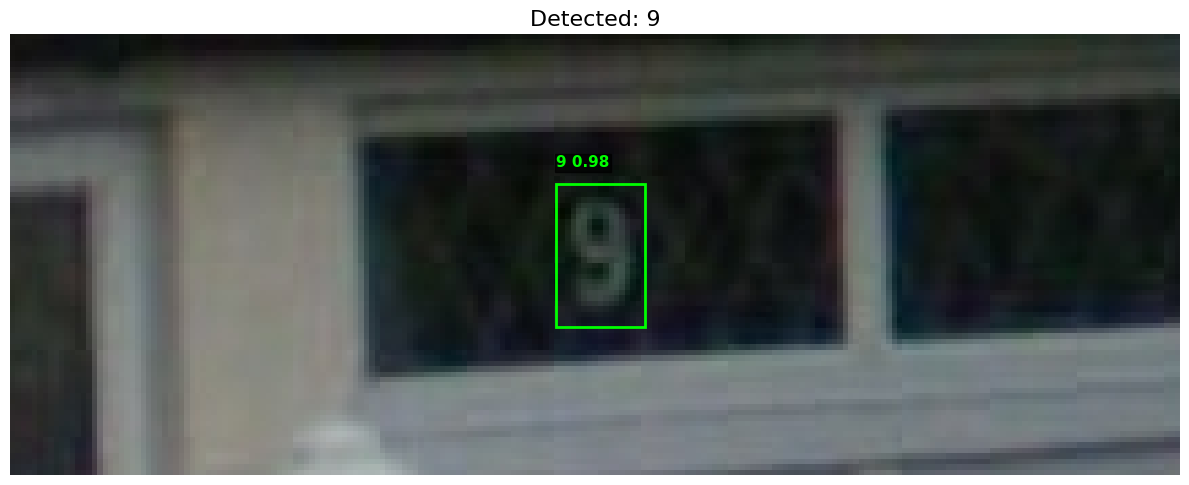

'9'

In [9]:
detect_and_show(os.path.join(DATA_DIR, 'test', '5.png'))

Тест на моих фотографиях

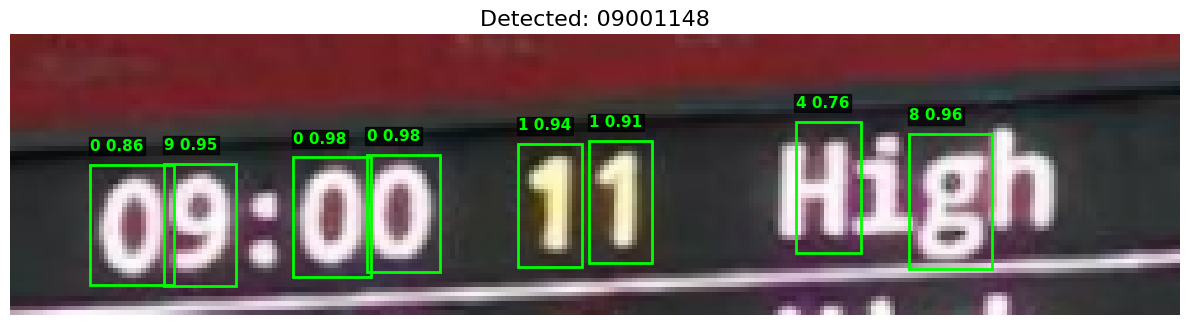

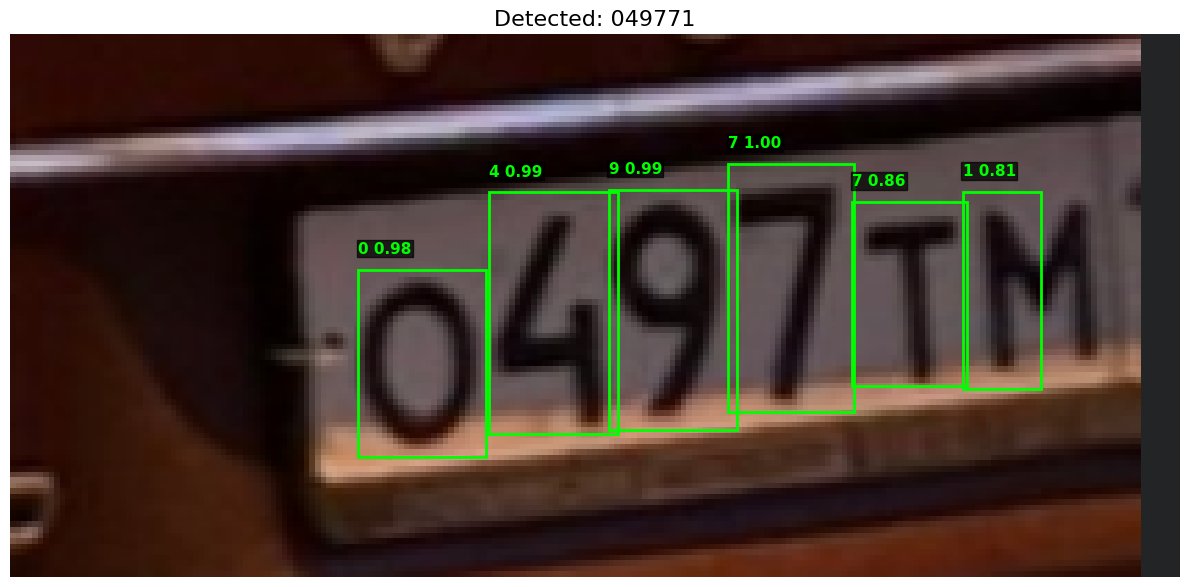

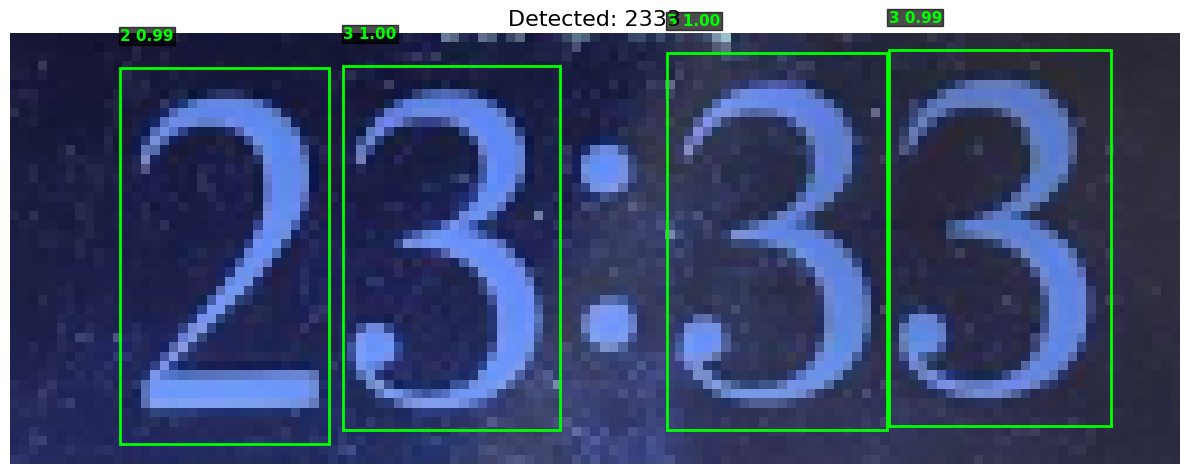

In [10]:
MY_PHOTOS = 'my_photos'
if os.path.exists(MY_PHOTOS):
    for fname in sorted(os.listdir(MY_PHOTOS)):
        detect_and_show(os.path.join(MY_PHOTOS, fname))